In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import pickle

In [2]:
df = pd.read_csv("phishing_url2.csv")
df.head()

,URL,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
0,https://keraekken-loagginnusa.godaddysites.com/,47,0,2,1,4.250669,6,1,1,3,1,1,0,1,0,12,0.0,0.0
1,https://metamsk01lgiix.godaddysites.com/,40,0,2,1,4.196439,6,1,1,3,1,0,2,1,0,12,5.0,0.0
2,http://myglobaltech.in/,23,0,1,0,3.936180,5,0,1,2,1,0,0,0,0,12,0.0,0.0
3,http://djtool-for-spotify.com/,30,0,1,0,3.894740,5,0,1,3,1,1,0,1,0,18,0.0,0.0
4,https://scearmcoommunnlty.com/invent/freind/get,47,0,1,1,4.143127,7,0,1,3,18,0,0,1,0,17,0.0,0.0


In [3]:
df.shape

(101219, 18)

In [5]:
df=df[["URL","ClassLabel"]]
df["ClassLabel"].value_counts()

ClassLabel
0.0    63678
1.0    37540
Name: count, dtype: int64

In [6]:
df.head()

,URL,ClassLabel
0,https://keraekken-loagginnusa.godaddysites.com/,0.0
1,https://metamsk01lgiix.godaddysites.com/,0.0
2,http://myglobaltech.in/,0.0
3,http://djtool-for-spotify.com/,0.0
4,https://scearmcoommunnlty.com/invent/freind/get,0.0


In [ ]:
df[df["ClassLabel"].isnull()]

,URL,ClassLabel
65118,https://www.chocolatleroux.com,NaN


In [17]:
df.dropna(inplace=True)

In [18]:
df["ClassLabel"].isnull().any()

np.False_

In [19]:
X = df["URL"]
y = df["ClassLabel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 6),
    max_features=50000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [22]:
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [23]:
y_pred = model.predict(X_test_tfidf)

In [24]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9980735032602253

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     12736
         1.0       1.00      1.00      1.00      7508

    accuracy                           1.00     20244
   macro avg       1.00      1.00      1.00     20244
weighted avg       1.00      1.00      1.00     20244


Confusion Matrix:

[[12705    31]
 [    8  7500]]


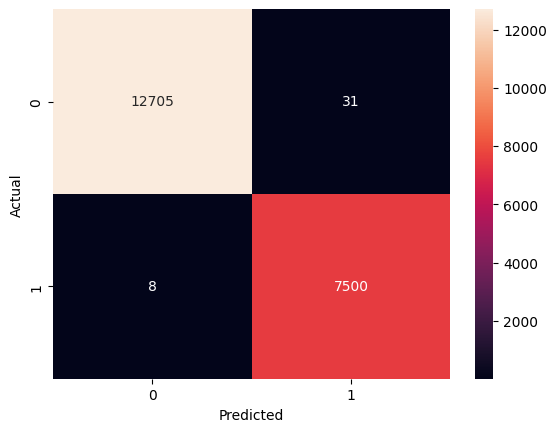

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
# Save model
with open("url_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("\nModel and vectorizer saved!")


Model and vectorizer saved!


In [26]:
def predict_url(url):
    x = vectorizer.transform([url])
    pred = model.predict(x)[0]

    return "Safe" if pred == 1 else "Malicious"

In [27]:
print(predict_url("https://google.com"))
print(predict_url("http://login-secure-bank.xyz"))

Safe
Malicious


In [28]:
safe_urls = [
    "https://www.google.com",
    "https://www.youtube.com",
    "https://www.wikipedia.org",
    "https://www.amazon.com",
    "https://www.facebook.com",
    "https://www.microsoft.com",
    "https://www.github.com",
    "https://www.stackoverflow.com",
    "https://www.netflix.com",
    "https://www.apple.com",
    "https://www.linkedin.com",
    "https://www.reddit.com",
    "https://www.bbc.com",
    "https://www.nytimes.com",
    "https://www.paypal.com"
]

malicious_urls = [
    "http://login-secure-bank.xyz",
    "http://verify-account-paypal.com.security-update.ru",
    "http://free-money-now.biz",
    "http://update-your-bank-info.com",
    "http://paypal-login-verification.net",
    "http://secure-google-login.xyz",
    "http://amazon-security-alert.co",
    "http://account-verification-required.info",
    "http://banking-login-update.ga",
    "http://confirm-your-password.ru",
    "http://secure-paypal-account-update.ml",
    "http://login-facebook-security-check.tk",
    "http://free-gift-card-claim-now.com",
    "http://update-netflix-payment.xyz",
    "http://click-here-to-win-prize.biz"
]

In [30]:
for i in malicious_urls:
    print(predict_url(i))

Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
Malicious
